# 02A · SAC 直觉与奖励设计：六道小挑战

这本是第二课的补充练习，可以单独运行，不依赖前一本的内存变量。
顺序：**先写预测 → 运行证据 → 解释反例 → 修改一个变量 → 复盘**。
默认只做数值练习与真实 Pendulum 仿真；不会训练大模型或启动云资源。第六题的两组 SAC 训练需自行打开开关。

任务是 **swing-up + stabilization**：从不同初始角度把摆摆起，再稳在正上方。
第一课 BC 有专家动作标签；本课没有动作标签，只有状态、实际动作、奖励和后继状态。
奖励定义“怎样算好”，SAC 是学习动作策略的算法；两者不是同一件事。

先用一个物理直觉：摆起阶段可能需要积累动能，接近正上方时需要制动。
因此“越慢越好”和“越省力越好”不能各自无限强化，要放在完整轨迹中权衡。

每题建议花 5–15 分钟解释；第六题的训练时间另记，不保证小预算收敛。
读完自己的结果后，再看 [参考解题提示](02A_参考解题提示.md)。

In [1]:
from pathlib import Path
import sys, time, json
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "sac_challenges.py").exists()), None)
if ROOT is None:
    raise RuntimeError("请在 robot_learning_loops 下打开这本 Notebook，并保留辅助文件。")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import gymnasium as gym
import numpy as np
import pandas as pd
from IPython.display import display, Image, Markdown
from sac_challenges import reward_terms, score, WeightedPendulum, zero_action, pd_action, rollout, metrics, soft_target
from common import plt, pendulum_frame, save_gif
from course_utils import begin_notebook, show_gif, preserve_cpu_rng
SEED = 7
RUN_REWARD_TRAINING = False
TRAIN_STEPS = 10000
CHECKPOINT = None  # 可填第二课保存的 sac_10000.zip 的完整路径
PREDICTIONS = {str(i): "待填写：我的预测和理由" for i in range(1, 7)}
OUT, manifest = begin_notebook("notebook02A", "02A_SAC直觉与奖励设计挑战.ipynb",
    dict(seed=SEED, reward_training=RUN_REWARD_TRAINING, train_steps=TRAIN_STEPS))
START = time.perf_counter()
print("默认不训练；所有运行结果写入：", OUT)

Results: runs/notebook02A-20260913-171527-120000
CPU threads: 2
默认不训练；所有运行结果写入： /Users/yddy/Desktop/playground/robotics2026/robot_learning_loops/runs/notebook02A-20260913-171527-120000


## 挑战 1 · 你会给哪个状态更高分？

先写出 A/B/C/D 的奖励，再运行下一格核对。训练目标中的一步奖励：

$$r_t=-\left(\bar\theta_t^2+0.1\omega_t^2+0.001u_t^2\right),\quad
\bar\theta_t=((\theta_t+\pi)\bmod 2\pi)-\pi.$$

纯文本：`reward = -(wrapped_angle**2 + 0.1*angular_velocity**2 + 0.001*torque**2)`。

- A：竖直向上，静止，不施力：`(0, 0, 0)`。
- B：竖直向上，但快速经过：`(0, 4, 0)`。
- C：正下方，静止，不施力：`(pi, 0, 0)`。
- D：偏离 0.2 rad，静止，使用最大正力矩：`(0.2, 0, 2)`。

问：为什么经过正上方还要扣分？平方意味着什么？如果把角度改成度而不改权重，会改变偏好吗？
成功条件：能手算每个成本项，知道这些是设计者选择的偏好，不是物理定律。

In [2]:
MY_REWARDS = None  # 填写例如 [A的奖励, B的奖励, C的奖励, D的奖励]
cases = [("A", 0., 0., 0.), ("B", 0., 4., 0.), ("C", np.pi, 0., 0.), ("D", .2, 0., 2.)]
reward_table = pd.DataFrame([dict(case=name, theta=theta, omega=omega, torque=u,
    **reward_terms(theta, omega, u), reward=float(score(theta, omega, u)))
    for name, theta, omega, u in cases])
display(reward_table)
if MY_REWARDS is not None:
    np.testing.assert_allclose(MY_REWARDS, reward_table.reward, atol=1e-6)
    print("手算核对 PASS")
else:
    print("待作答：将手算结果填入 MY_REWARDS，再核对。")
reward_table.to_csv(OUT / "challenge1_reward_terms.csv", index=False)

,case,theta,omega,torque,angle_cost,speed_cost,control_cost,reward
0,A,0.000000,0.0,0.0,0.000000,0.0,0.000,-0.000000
1,B,0.000000,4.0,0.0,0.000000,1.6,0.000,-1.600000
2,C,3.141593,0.0,0.0,9.869604,0.0,0.000,-9.869604
3,D,0.200000,0.0,2.0,0.040000,0.0,0.004,-0.044000


待作答：将手算结果填入 MY_REWARDS，再核对。


## 挑战 2 · 只优化眼前奖励，为什么会一直不出力？

固定同一个动作前状态，试 `[-2, -1, 0, 1, 2]` 五种力矩。
先预测：哪种动作的一步奖励最高？它是否也最有利于以后稳住？

每次都恢复同一个状态，不把五个动作串在一起执行。
这里奖励的角度和速度来自动作前；返回的 next_obs 来自动作后。当前 u 会影响下一步状态，但当前成本里的状态项不会立刻随 u 改变。
所以只最大化当前奖励会选 u=0。这是长期价值估计存在的具体理由。

改题：将 INITIAL 改为 `(0.2, 2.)`，解释“刹车可能值得付出当前力矩成本”。

In [3]:
INITIAL = (1., 0.)
one_step = []
for u in [-2., -1., 0., 1., 2.]:
    trace = rollout(lambda obs, torque=u: [torque], initial=INITIAL, max_steps=1)
    row = trace.iloc[0].to_dict()
    row["recomputed_pre_reward"] = float(score(row["theta"], row["omega"], row["torque"]))
    row["wrong_post_reward"] = float(score(row["next_theta"], row["next_omega"], row["torque"]))
    one_step.append(row)
one_step = pd.DataFrame(one_step)
display(one_step[["torque", "reward", "next_theta", "next_omega", "wrong_post_reward"]])
np.testing.assert_allclose(one_step.reward, one_step.recomputed_pre_reward)
print("只看本步奖励选：", one_step.loc[one_step.reward.idxmax(), "torque"])
one_step.to_csv(OUT / "challenge2_pre_post.csv", index=False)

,torque,reward,next_theta,next_omega,wrong_post_reward
0,-2.0,-1.004,1.016555,0.331103,-1.048347
1,-1.0,-1.001,1.024055,0.481103,-1.072835
2,0.0,-1.000,1.031555,0.631103,-1.103935
3,1.0,-1.001,1.039055,0.781103,-1.141648
4,2.0,-1.004,1.046555,0.931103,-1.185973


只看本步奖励选： 0.0


## 挑战 3 · 没有专家答案，critic 向谁学习？

SAC 是 **Soft Actor-Critic**：Actor 提议动作；Critic 估计从当前观察和动作出发、继续执行策略的长期价值；Soft 指目标中含策略熵。
Replay buffer 保存真实 `(o, a, r, next_o, terminated, truncated)`，允许反复使用旧交互。Q 不是“下一步奖励预测器”。

以下是现代双 Q SAC 的目标示意（用观察 o 代替完整状态记号）：

$$y=r+\gamma(1-d)\left[\min(Q'_1(o',a'),Q'_2(o',a'))-\alpha\log\pi(a'|o')\right].$$

`a'` 从当前策略采样，`Q'` 是慢更新的目标网络，d 只标识真正终止。
Critic 拟合 `(Q(o,a)-y)**2`；Actor 通过 critic 的评价改进动作，常写作最小化 `alpha*log_pi - min(Q1,Q2)`。
取两套 Q 的较小值有助于抑制过高估计，不是置信区间，更不保证判断正确。

这一题的 Q 和 log_pi 是**人为设置的教学数字，不是训练结果**。
先令 alpha=0，观察即时奖励较差的动作能否因为后续价值更好而胜出；再打开 alpha。
成功条件：解释真实奖励如何与当前价值估计组成不断变化的训练目标，以及为何时间截断不把后续价值清零。

In [4]:
ALPHA = 0.1
toy = pd.DataFrame([
    dict(choice="不动", r=-np.pi**2, q1=-100., q2=-105., log_pi=-.5),
    dict(choice="施力摆动", r=-(np.pi**2+.004), q1=-20., q2=-25., log_pi=-.5),
])
toy["target_without_entropy"] = soft_target(toy.r, toy.q1, toy.q2, toy.log_pi, False, alpha=0.)
toy["target_timeout"] = soft_target(toy.r, toy.q1, toy.q2, toy.log_pi, False, alpha=ALPHA)
toy["target_true_terminal"] = soft_target(toy.r, toy.q1, toy.q2, toy.log_pi, True, alpha=ALPHA)
display(toy)
MY_EXPLANATION_3 = "待填写：为什么当前更费力仍可能值得？为什么 timeout 不等于 true terminal？"

,choice,r,q1,q2,log_pi,target_without_entropy,target_timeout,target_true_terminal
0,不动,-9.869604,-100.0,-105.0,-0.5,-113.819604,-113.770104,-9.869604
1,施力摆动,-9.873604,-20.0,-25.0,-0.5,-34.623604,-34.574104,-9.873604


## 挑战 4 · Soft 是“动作轻柔”吗？探索到底值多少？

不是。Soft 指熵正则化：不要过早把概率全压在某一个动作上。
下面用三个离散候选动作演示 `E[Q] + alpha*H` 的权衡；**真实本课 SAC 使用连续动作分布，这不是重新实现 SAC**。

先预测 alpha=0 与 alpha=0.2 时哪种分布获胜。更分散不是总更好，alpha 太大可能牺牲控制质量。
本课 `ent_coef="auto"` 是学习熵系数来匹配目标熵；它不是保证奖励最大，也不是让熵永远增加。

In [5]:
q_values = np.array([-4., -3.9, -4.1])
distributions = {"集中": np.array([0., 1., 0.]), "分散": np.array([.25, .5, .25])}
entropy_rows = []
for alpha in [0., .2]:
    for name, probabilities in distributions.items():
        positive = probabilities[probabilities > 0]
        entropy = -float(np.sum(positive*np.log(positive)))
        expected_q = float(probabilities @ q_values)
        entropy_rows.append(dict(alpha=alpha, policy=name, expected_q=expected_q,
            entropy=entropy, score=expected_q+alpha*entropy))
display(pd.DataFrame(entropy_rows))
MY_EXPLANATION_4 = "待填写：为什么探索有价值，但评测时不能把更随机当成更成功？"

,alpha,policy,expected_q,entropy,score
0,0.0,集中,-3.900,-0.000000,-3.900000
1,0.0,分散,-3.975,1.039721,-3.975000
2,0.2,集中,-3.900,-0.000000,-3.900000
3,0.2,分散,-3.975,1.039721,-3.767056


## 挑战 5 · 稳得住，等于摆得起来吗？再加 100 ms 延迟呢？

真实模拟比较两个不用训练的基线：零动作、简单 PD（位置误差与速度反馈）。
两种初始状态：接近正上方、从正下方开始；正常与两步观测延迟分别测试。
PD 默认参数只作为局部反馈基线，**不承诺能全局摆起**。结果以真实运行表格为准。

如果第二课已经训练完，可在开头 CHECKPOINT 填入相应 zip，重跑设置和本格，加入 SAC 对照。
先预测哪个场景最难，再比较：原始回报、向上时间比例、平均力矩平方、峰值速度。
平均力矩平方是控制努力代理指标，不是真实电能消耗。

成功条件：区分 swing-up 与 stabilization；理解观测延迟使反馈过时；不会用单个回放证明泛化。

本次只比较基线；已有 SAC checkpoint 示例： /Users/yddy/Desktop/playground/robotics2026/robot_learning_loops/runs/notebook02-20260913-163331-279000/sac_10000.zip


,policy,initial,delay_ms,original_return,upright_fraction,mean_torque_squared,peak_speed,steps
0,zero,near_up,0,-503.2456,0.36,0.0000,7.7494,200
1,zero,near_up,100,-503.2456,0.36,0.0000,7.7494,200
2,zero,down,0,-1973.9209,0.00,0.0000,0.0000,200
3,zero,down,100,-1973.9209,0.00,0.0000,0.0000,200
4,pd,near_up,0,-0.1434,1.00,0.0177,0.0348,200
5,pd,near_up,100,-0.1025,1.00,0.0129,0.0613,200
6,pd,down,0,-1471.8620,0.00,4.0000,1.9192,200
7,pd,down,100,-1502.1701,0.00,4.0000,1.5667,200


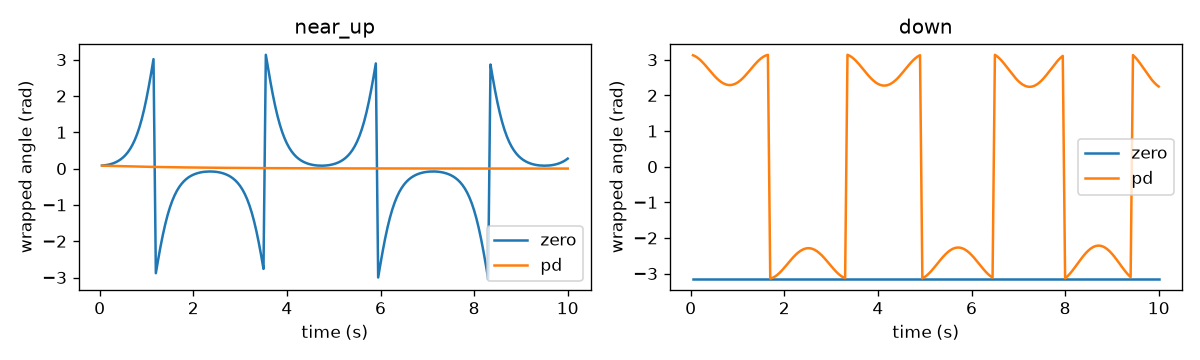


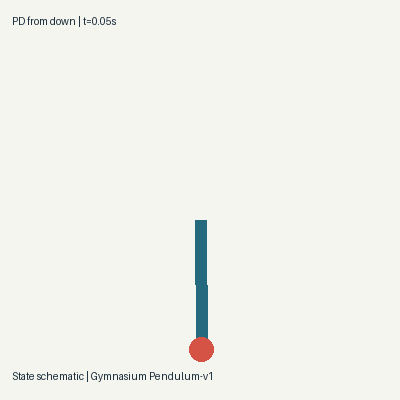

In [6]:
controllers = {"zero": zero_action, "pd": pd_action}
if CHECKPOINT is not None:
    from stable_baselines3 import SAC
    with preserve_cpu_rng():
        frozen = SAC.load(Path(CHECKPOINT), device="cpu")
    controllers["sac"] = lambda obs: frozen.predict(obs, deterministic=True)[0]
else:
    available = sorted(ROOT.glob("runs/notebook02-*/sac_10000.zip"))
    print("本次只比较基线；已有 SAC checkpoint 示例：", str(available[-1]) if available else "尚未找到")
traces, scores = {}, []
for name, controller in controllers.items():
    for initial_name, initial in {"near_up": (.08, 0.), "down": (np.pi, 0.)}.items():
        for delay in [0, 2]:
            trace = rollout(controller, initial=initial, delay=delay)
            traces[(name, initial_name, delay)] = trace
            scores.append(dict(policy=name, initial=initial_name, delay_ms=delay*50, **metrics(trace)))
            trace.to_csv(OUT / f"challenge5_{name}_{initial_name}_delay{delay}.csv", index=False)
display(pd.DataFrame(scores).round(4))
pd.DataFrame(scores).to_csv(OUT / "challenge5_scores.csv", index=False)
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for name in controllers:
    for ax, initial_name in zip(axes, ["near_up", "down"]):
        trace = traces[(name, initial_name, 0)]
        ax.plot(trace.next_time, trace.next_theta, label=name)
        ax.set(xlabel="time (s)", ylabel="wrapped angle (rad)", title=initial_name)
        ax.legend()
fig.tight_layout(); fig.savefig(OUT / "challenge5_angles.png", dpi=120); plt.close(fig)
display(Image(filename=str(OUT / "challenge5_angles.png")))
trace = traces[("pd", "down", 0)]
frames = [pendulum_frame([np.cos(row.next_theta), np.sin(row.next_theta), row.next_omega],
    f"PD from down | t={row.next_time:.2f}s") for row in trace.iloc[::4].itertuples()]
save_gif(frames, OUT / "challenge5_pd_down.gif", duration=200)
del frames
show_gif(OUT / "challenge5_pd_down.gif")

## 挑战 6 · “省力”权重提高后，是更聪明还是更不愿动？

设计一个产品目标：摆起并保持向上，同时尽量少用驱动。
将控制成本权重由 0.001 改到 1.0，固定其他训练配置，比较两条独立训练轨迹。
这不是推荐权重，而是用于暴露权衡的大幅干预。

在首格设 `RUN_REWARD_TRAINING=True` 才执行两次训练，默认每组 10k 环境步。
运行前填预测；保持学习率、架构、预算、训练 seed、原始物理环境相同。改奖励会改变探索轨迹，这是干预的一部分。
统一用**未修改奖励的环境**和相同开发 seeds 评测；新奖励只作为附加重评分，不能跨不同打分规则宣布赢家。

题目：预先选一个向上时间比例门槛，例如 0.8（自己定的产品门槛，不是官方指标），再在满足门槛的方案中比较控制努力。
若两组均不达标，结论是当前预算/配置没有满足要求，不是挑较高分者宣布成功。
之后用 7/11/19 三个训练 seed 重复，冻结方案后再使用新的最终测试初始条件。

In [7]:
reward_experiment = []
if RUN_REWARD_TRAINING:
    from stable_baselines3 import SAC
    from stable_baselines3.common.logger import configure
    for label, penalty in [("original", .001), ("effort_heavy", 1.)]:
        run_dir = OUT / label
        run_dir.mkdir(exist_ok=True)
        env = WeightedPendulum((1., .1, penalty))
        started = time.perf_counter()
        try:
            agent = SAC("MlpPolicy", env, policy_kwargs={"net_arch": [64, 64]},
                seed=SEED, device="cpu", verbose=0, buffer_size=TRAIN_STEPS+1000,
                learning_starts=500, batch_size=128, learning_rate=1e-3,
                train_freq=1, gradient_steps=1, gamma=.99, ent_coef="auto")
            agent.set_logger(configure(str(run_dir / "training"), ["csv"]))
            agent.learn(total_timesteps=TRAIN_STEPS, log_interval=1)
            agent.save(run_dir / "policy")
            config = dict(weights=[1., .1, penalty], seed=SEED, requested_steps=TRAIN_STEPS,
                actual_steps=int(agent.num_timesteps), updates=int(agent._n_updates),
                seconds=time.perf_counter()-started, evaluation_seeds=list(range(12000, 12008)))
            (run_dir / "config.json").write_text(json.dumps(config, indent=2))
            for eval_seed in config["evaluation_seeds"]:
                trace = rollout(lambda obs: agent.predict(obs, deterministic=True)[0], seed=eval_seed)
                trace.to_csv(run_dir / f"eval_{eval_seed}.csv", index=False)
                reward_experiment.append(dict(variant=label, seed=eval_seed, **metrics(trace),
                    own_reward_rescore=float(score(trace.theta, trace.omega, trace.torque, (1., .1, penalty)).sum())))
        finally:
            env.close()
    reward_experiment = pd.DataFrame(reward_experiment)
    reward_experiment.to_csv(OUT / "challenge6_paired_episodes.csv", index=False)
    display(reward_experiment.groupby("variant")[["original_return", "upright_fraction", "mean_torque_squared", "peak_speed"]].mean())
    print("只代表一个训练 seed；own_reward_rescore 不能跨奖励版本直接比较。")
else:
    print("挑战 6 未训练。先完成前五题，再按需打开 RUN_REWARD_TRAINING。")

挑战 6 未训练。先完成前五题，再按需打开 RUN_REWARD_TRAINING。


## 一般怎样选择目标函数？

先写外部验收条件，再选择训练信号：

1. **任务结果**：例如摆起后保持、达到时间、失败率；不要只说“reward 高”。
2. **约束**：动作范围、碰撞、温度、速度等；硬约束不能仅靠一个有限惩罚承诺满足。
3. **成本分解**：追踪误差、运动状态、控制努力、动作变化率等，按任务需要选，别默认越多越好。
4. **单位与尺度**：可先按容忍尺度写 `(angle/angle_tol)**2` 等无量纲项，再选权重。并非一定做训练集 z-score。
5. **时间与探索**：gamma 控制未来影响的折扣；SAC 的 alpha 控制回报与熵的相对权衡。奖励整体缩放也会影响它们的相对尺度和优化过程。
6. **对抗检查**：不动能否刷分？快速掠过目标能否刷分？撞击、抖动、拖延结束有没有漏洞？用固定物理指标复评。

平方误差平滑、非负、对正负偏差对称且更重罚大误差，是常见设计，不是唯一正确形式。
0.1、0.001 是基准设计权重，具有尺度含义；不是概率，也不是从物理方程必然推导出的常数。
速度惩罚不是动作平滑惩罚，力矩平方也不等于真实能耗。

## 哪些应用适合借用这个学习思路？

- 可在仿真中反复试验的连续控制，例如机械臂调节、平衡和运动控制。
- 目标与约束可明确表达、状态动作可观测、试错成本可控制的调节问题。
- 真机应用还需处理安全、延迟、接触、部分可观测性和仿真误差；本摆没有解决这些部署问题。
- 量化类比适合解释长期决策与成本权衡，但历史行情不是可随意交互的真实市场，不能把本课直接当交易策略配方。

随用随读：[Pendulum](https://gymnasium.farama.org/environments/classic_control/pendulum/)、
[SAC 直觉与公式](https://spinningup.openai.com/en/latest/algorithms/sac.html)、
[本课使用的 SB3 SAC](https://stable-baselines3.readthedocs.io/en/master/modules/sac.html)。

In [8]:
REVIEW = {
    "1_奖励三项分别防止什么坏行为": "待填写",
    "2_为什么只贪本步奖励会不出力": "待填写",
    "3_critic没有专家标签如何更新": MY_EXPLANATION_3,
    "4_soft与动作轻柔有何区别": MY_EXPLANATION_4,
    "5_局部稳定和全局摆起的证据": "待填写：引用 challenge5 的两个数",
    "6_新奖励的外部验收条件与结论": "待填写；未训练则明确写未训练",
}
payload = dict(predictions=PREDICTIONS, review=REVIEW,
    reward_training_ran=RUN_REWARD_TRAINING, elapsed_seconds=time.perf_counter()-START)
(OUT / "my_review.json").write_text(json.dumps(payload, ensure_ascii=False, indent=2))
print("复盘已保存；修改回答后可单独重跑此格：", OUT / "my_review.json")

复盘已保存；修改回答后可单独重跑此格： /Users/yddy/Desktop/playground/robotics2026/robot_learning_loops/runs/notebook02A-20260913-171527-120000/my_review.json
